In [1]:
setwd("/home/mjehangir/telomere-sv-analysis/data/")


In [2]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
library(ggridges)
library(tidyverse)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [3]:
# RTL matrix (assumes tab-delimited, sample IDs as rownames)
rtl_matrix <- read.table("telomeres_RTL_matrix.txt", sep = "\t", header = TRUE, check.names = FALSE, row.names = 1)

# CNV + telomere data file (space-delimited or tab-delimited with uneven spacing)
sv <- read.table("sv_summary_rate_prop_pq.tsv", sep = "", header = TRUE, fill = TRUE, stringsAsFactors = FALSE)
cnv <- read.table("cnvs_summary_rate_prop_pq.tsv", sep = "", header = TRUE, fill = TRUE, stringsAsFactors = FALSE)
head(sv)
head(cnv)
head(rtl_matrix)

,type,chr,Sample_ID,arm,arm_size,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,chr_arm
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,DEL,chr1,2436A,p,124048267,581,0.201164,124.0483,4.683661,0.001621659,chr1p
2,DEL,chr1,2436A,q,124339061,551,0.173200,124.3391,4.431431,0.001392965,chr1q
3,DEL,chr1,3188,p,124048267,330,389.636135,124.0483,2.660255,3.141004259,chr1p
4,DEL,chr1,3188,q,124339061,378,82.339694,124.3391,3.040074,0.662219043,chr1q
5,DEL,chr1,3988,p,124048267,523,0.256730,124.0483,4.216101,0.002069598,chr1p
6,DEL,chr1,3988,q,124339061,459,0.194912,124.3391,3.691519,0.001567585,chr1q


,ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.33906,0.008042525,0.001609727,chr1q
2,2436A,chr10,q,Loss,17.220193,2,94108943,94.10894,0.021251965,0.182981473,chr10q
3,2436A,chr10,q,Loss,17.220193,2,94108943,94.10894,0.021251965,0.182981473,chr10q
4,2436A,chr15,q,Gain,1.602465,1,82566565,82.56656,0.012111440,0.019408159,chr15q
5,2436A,chr18,q,Loss,0.200356,1,62092914,62.09291,0.016104897,0.003226713,chr18q
6,2436A,chr19,q,Loss,7.012181,1,33914441,33.91444,0.029485964,0.206760919,chr19q


,chr1p,chr1q,chr2p,chr2q,chr3p,chr3q,chr4p,chr4q,chr5p,chr5q,⋯,chr18p,chr18q,chr19p,chr19q,chr20p,chr20q,chr21p,chr21q,chr22q,chr22p
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,1.0340362,1.0004002,0.8156330,1.3790450,0.9386141,0.8076712,1.1463819,0.8365606,1.2964073,2.0879190,⋯,0.4487557,0.7188344,1.2516473,0.9000532,1.1303099,0.8671565,1.3062770,1.8780601,1.4002566,NA
3188,0.3253025,0.6112915,0.6811548,0.3818467,0.5724730,0.4675642,0.5065873,0.8148903,0.7290342,0.4273990,⋯,0.4408666,0.5692547,0.6179593,0.5857756,0.5790583,0.5680663,0.5869309,0.7339855,0.5299906,0.5204444
3988,0.4649301,1.0067049,0.6723909,NA,1.9879599,0.4228862,0.8322199,1.1357366,1.1266591,1.2130104,⋯,0.8688598,1.1966380,0.4061578,1.4510374,0.6424849,1.3914234,1.6646379,1.7905008,1.4363155,1.6553294
6265D,1.2968529,0.7736622,0.9596425,1.1364298,1.0555250,0.9145111,NA,1.0008128,1.4014251,NA,⋯,1.1702309,1.1801995,0.7922132,1.2982393,1.1013743,0.8962159,2.0864666,1.2655605,1.5958144,1.1281115
6266D,0.8365771,0.8592542,0.8857933,0.8644531,2.5409247,1.1015724,1.3689443,NA,0.8289520,0.6678357,⋯,1.7196967,1.0448631,0.9826343,1.0439389,0.7231916,0.3794701,0.9437239,1.4404416,1.7191025,0.7821124
6269C,0.7959762,0.9420999,1.2097590,0.6383257,1.8163467,0.8837385,0.7049707,0.9182246,1.1749511,0.6096080,⋯,1.1760404,1.0270548,NA,1.0480980,0.6589728,1.0994928,0.7546821,0.5416757,0.7880540,1.1874285


Warning message:
“There were 18 warnings in `summarise()`.
The first warning was:
ℹ In argument: `r = safe_cor(value, RTL)`.
ℹ In group 20: `Gain_Loss = "Gain"` `chr_arm = "chr21q"`.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 17 remaining warnings.”
Warning message:
“There were 4 warnings in `summarise()`.
The first warning was:
ℹ In argument: `r = safe_cor(value, RTL)`.
ℹ In group 54: `Gain_Loss = "Loss"` `chr_arm = "chr20q"`.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”
Warning message:
“There were 13 warnings in `summarise()`.
The first warning was:
ℹ In argument: `r = safe_cor(value, RTL)`.
ℹ In group 59: `type = "DUP"` `chr_arm = "chr19p"`.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 12 remaining warnings.”


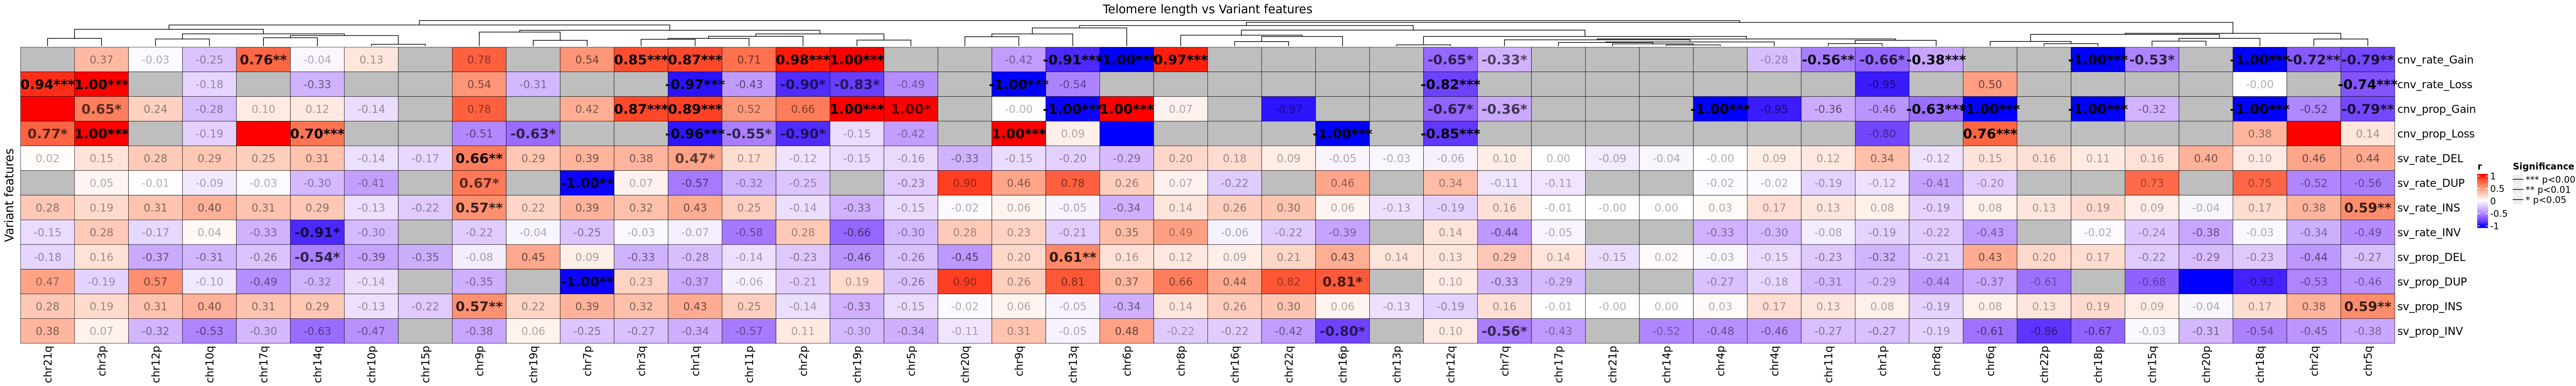

In [19]:
#–––– Libraries ––––
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(grid)

#–––– Step 1: Convert RTL to long format ––––
rtl_long <- rtl_matrix %>%
  rownames_to_column("Sample_ID") %>%
  pivot_longer(cols = -Sample_ID, names_to = "chr_arm", values_to = "RTL")

#–––– Step 2: Prepare CNV data ––––
cnv_sel <- cnv %>%
  rename(Sample_ID = ID, chr_arm = arm) %>%
  filter(Gain_Loss %in% c("Gain", "Loss")) %>%
  select(Sample_ID, chr_arm, Gain_Loss, cnv_rate_per_mb, cnv_proportion_per_mb)

#–––– Step 3: Prepare SV data with all types included ––––
sv_sel <- sv %>%
  filter(type %in% c("DEL", "DUP", "INV", "INS"))
# No Gain_Loss column here — we will group by type only

#–––– Step 4: Safe correlation function ––––
safe_cor <- function(x, y) {
  if (sum(complete.cases(x, y)) > 1) cor(x, y, use = "complete.obs") else NA
}

#–––– Step 5: Correlation and p-value calculation with SV grouped by type only ––––
cor_by_arm <- function(df, value_col, var_prefix) {
  df <- df %>% inner_join(rtl_long, by = c("Sample_ID", "chr_arm")) %>% filter(!is.na(RTL))
  
  # Define grouping columns based on what exists
  if ("type" %in% colnames(df)) {
    group_vars <- c("type", "chr_arm")
  } else if ("Gain_Loss" %in% colnames(df)) {
    group_vars <- c("Gain_Loss", "chr_arm")
  } else {
    group_vars <- "chr_arm"
  }
  
  df <- df %>%
    mutate(value = .data[[value_col]])
  
  summarised <- df %>%
    group_by(across(all_of(group_vars))) %>%
    summarise(
      r = safe_cor(value, RTL),
      p = if (sum(complete.cases(value, RTL)) > 2) cor.test(value, RTL)$p.value else NA_real_,
      .groups = "drop"
    )
  
  summarised <- summarised %>%
    mutate(variable = if ("type" %in% group_vars) {
      paste0(var_prefix, "_", type)
    } else if ("Gain_Loss" %in% group_vars) {
      paste0(var_prefix, "_", Gain_Loss)
    } else {
      var_prefix
    })
  
  summarised
}

# CNV correlations (grouped by Gain_Loss)
cnv_r1 <- cor_by_arm(cnv_sel, "cnv_rate_per_mb", "cnv_rate")
cnv_r2 <- cor_by_arm(cnv_sel, "cnv_proportion_per_mb", "cnv_prop")

# SV correlations (grouped by type only)
sv_r1  <- cor_by_arm(sv_sel, "sv_rate", "sv_rate")
sv_r2  <- cor_by_arm(sv_sel, "sv_proportion", "sv_prop")

# Combine all correlation data
cor_df <- bind_rows(cnv_r1, cnv_r2, sv_r1, sv_r2)

#–––– Step 6: Create correlation and p-value matrices ––––
corr_matrix_p_q <- cor_df %>%
  select(variable, chr_arm, r) %>%
  pivot_wider(names_from = chr_arm, values_from = r) %>%
  column_to_rownames("variable") %>%
  as.matrix()

pval_matrix_p_q <- cor_df %>%
  select(variable, chr_arm, p) %>%
  pivot_wider(names_from = chr_arm, values_from = p) %>%
  column_to_rownames("variable") %>%
  as.matrix()

#–––– Step 7: Plotting the heatmap ––––
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))

pval_to_stars <- function(p) {
  if      (p < 0.001) return("***")
  else if (p < 0.01 ) return("**")
  else if (p < 0.05 ) return("*")
  else                 return("")
}

heatmap_p_q <- Heatmap(
  corr_matrix_p_q,
  name                 = "Correlation",
  col                  = col_fun,
  na_col               = "grey",
  rect_gp              = gpar(col = "black", lwd = 0.5),
  cluster_rows         = FALSE,
  cluster_columns      = TRUE,
  column_title         = "Telomere length vs Variant features",
  row_title            = "Variant features",
  heatmap_legend_param = list(title = "r"),
  cell_fun = function(j, i, x, y, width, height, fill) {
    pval <- pval_matrix_p_q[i, j]
    if (!is.na(pval)) {
      r_val  <- corr_matrix_p_q[i, j]
      stars  <- pval_to_stars(pval)
      is_sig <- nzchar(stars)
      
      fs      <- if (is_sig) 15 else 12
      fface   <- if (is_sig) "bold" else "plain"
      
      log_p    <- -log10(pval)
      alpha    <- min(log_p / 3, 1)
      text_a   <- 0.3 + 0.7 * alpha
      text_col <- rgb(0, 0, 0, text_a)
      
      grid.text(
        sprintf("%.2f%s", r_val, stars),
        x, y,
        gp = gpar(fontsize = fs, fontface = fface, col = text_col)
      )
    }
  }
)

# Optional significance legend
p_legend <- Legend(
  title = "Significance",
  labels = c("*** p<0.001", "** p<0.01", "* p<0.05"),
  legend_gp = gpar(fill = NA),
  type = "lines"
)

# Draw the heatmap
draw(heatmap_p_q, annotation_legend_list = list(p_legend))
options(repr.plot.width = 40, repr.plot.height = 6, repr.plot.res = 200)


In [8]:
library(dplyr)

summary_simple <- cor_df %>%
  filter(!is.na(r)) %>%
  group_by(variable) %>%
  summarise(
    mean_r = mean(r, na.rm = TRUE),                 # average correlation
    sig_pos_count = sum(r > 0 & p < 0.05, na.rm = TRUE),  # count positive significant correlations
    sig_neg_count = sum(r < 0 & p < 0.05, na.rm = TRUE),  # count negative significant correlations
    total_arms = n()                                # total number of arms / data points
  ) %>%
  ungroup() %>%
  mutate(
    direction = case_when(
      mean_r > 0 ~ "Positive",
      mean_r < 0 ~ "Negative",
      TRUE ~ "Neutral"
    )
  )


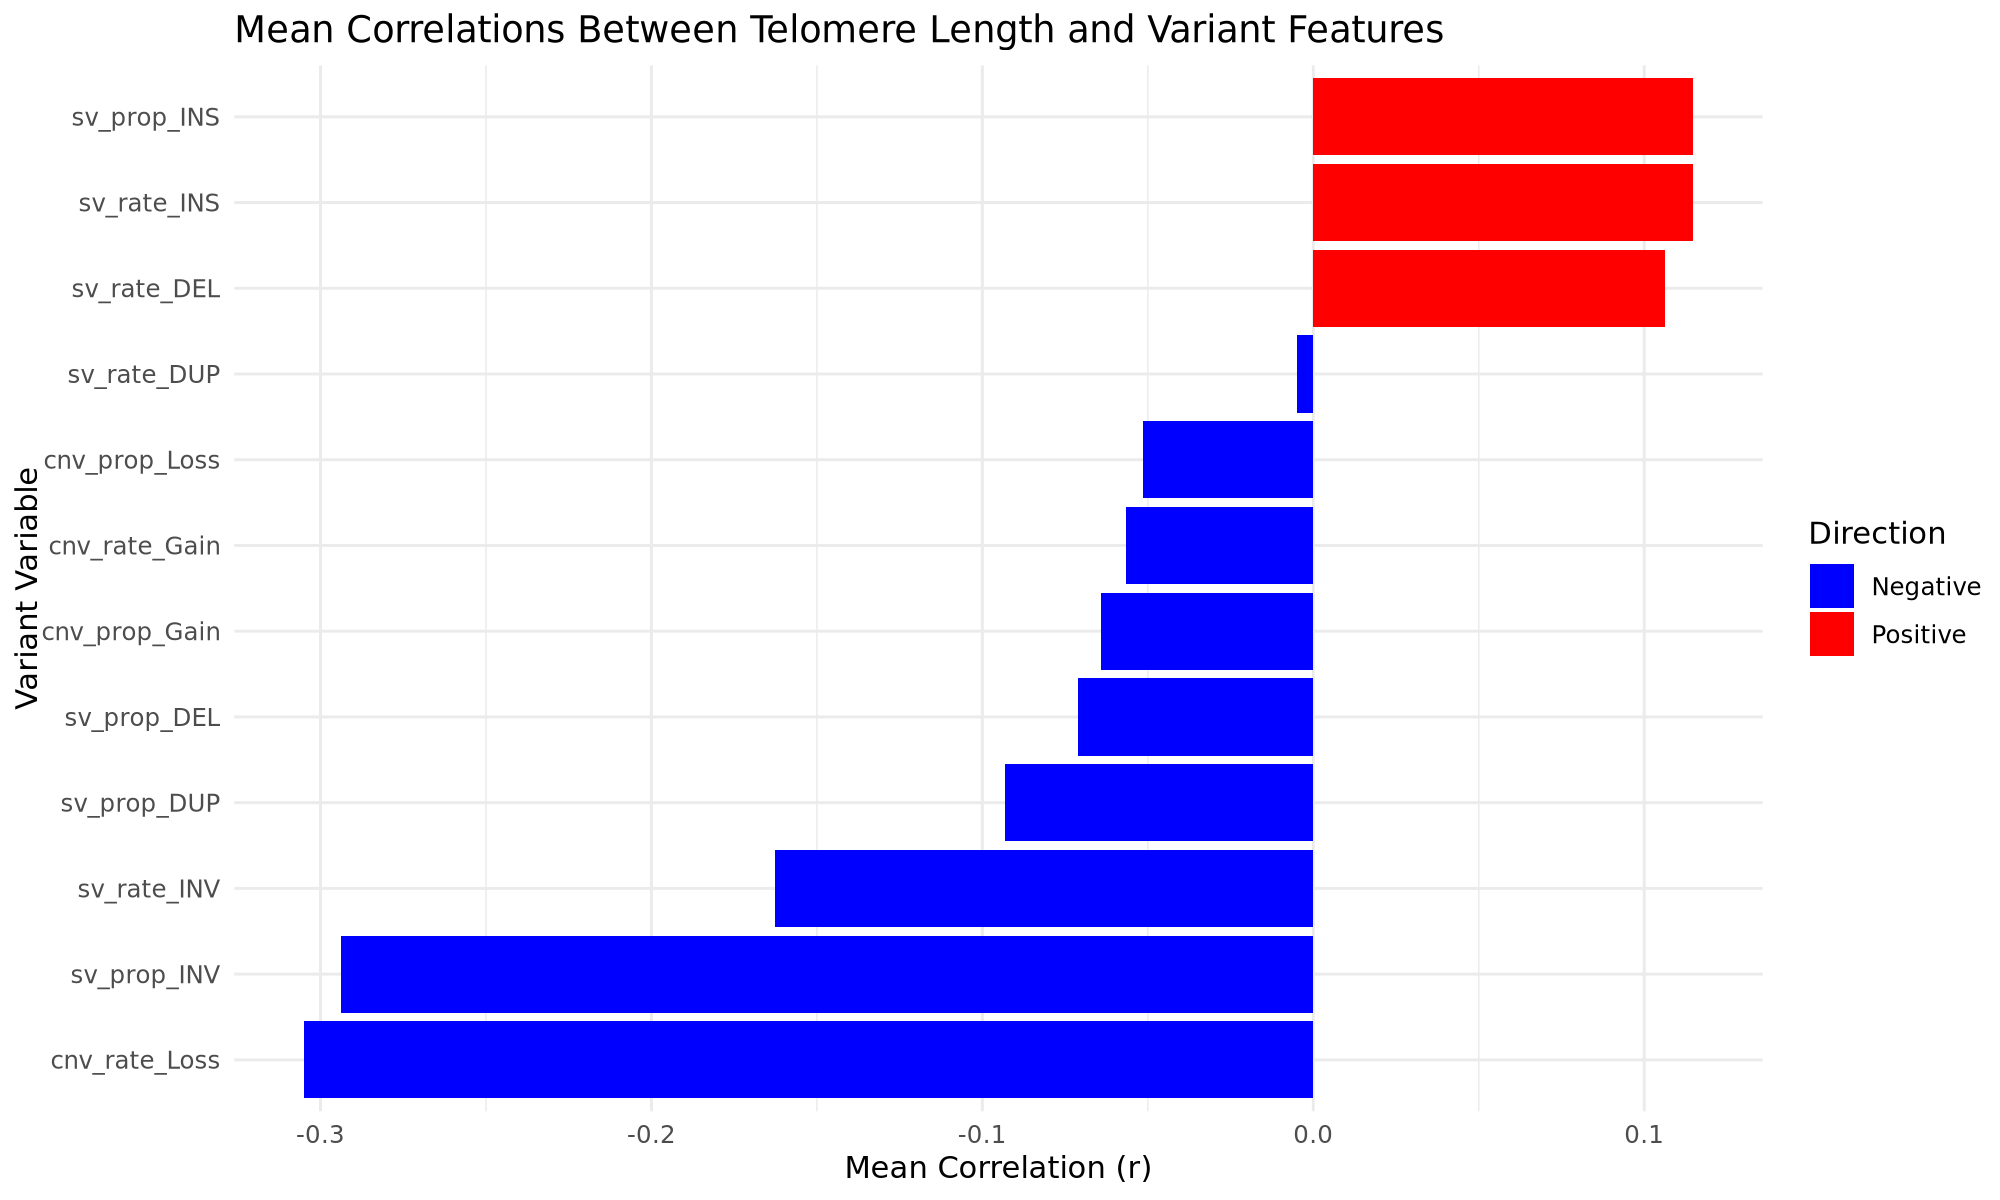

In [11]:
library(ggplot2)
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 200)

ggplot(summary_simple, aes(x = reorder(variable, mean_r), y = mean_r, fill = direction)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("Positive" = "red", "Negative" = "blue", "Neutral" = "grey")) +
  labs(x = "Variant Variable", y = "Mean Correlation (r)", fill = "Direction",
       title = "Mean Correlations Between Telomere Length and Variant Features") +
  theme_minimal()


In [ ]:
head(summary_simple)